In [22]:
import pandas as pd

df = pd.read_csv('../data/raw/Amazon Sale Report.csv')

df.head()
df.info()
df.columns

C:\Users\mogal\AppData\Local\Temp\ipykernel_9596\34348304.py:3: DtypeWarning: Columns (0: Unnamed: 22) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/raw/Amazon Sale Report.csv')


<class 'pandas.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128975 non-null  int64  
 1   Order ID            128975 non-null  str    
 2   Date                128975 non-null  str    
 3   Status              128975 non-null  str    
 4   Fulfilment          128975 non-null  str    
 5   Sales Channel       128975 non-null  str    
 6   ship-service-level  128975 non-null  str    
 7   Style               128975 non-null  str    
 8   SKU                 128975 non-null  str    
 9   Category            128975 non-null  str    
 10  Size                128975 non-null  str    
 11  ASIN                128975 non-null  str    
 12  Courier Status      122103 non-null  str    
 13  Qty                 128975 non-null  int64  
 14  currency            121180 non-null  str    
 15  Amount              121180 non-null  float64


Index(['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ',
       'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN',
       'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city',
       'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids',
       'B2B', 'fulfilled-by', 'Unnamed: 22'],
      dtype='str')

In [23]:
# Remove duplicates
df.drop_duplicates(inplace=True)

# Handle missing values
df.isnull().sum()

# Drop rows where Amount is missing
df = df[df['Amount'].notna()]

# Convert date
df['Date'] = pd.to_datetime(df['Date'])

# Fix column names (clean format)
df.columns = df.columns.str.lower().str.replace(' ', '_')

# Rename for clarity
df.rename(columns={
    'amount': 'revenue',
    'qty': 'quantity'
}, inplace=True)

# Filter only completed orders
df = df[df['status'] == 'Shipped']

# Save cleaned data
df.to_csv('../data/cleaned/amazon_cleaned.csv', index=False)

C:\Users\mogal\AppData\Local\Temp\ipykernel_9596\3600028859.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'])


In [24]:
# Extract time features
df['month'] = df['date'].dt.to_period('M')
df['year'] = df['date'].dt.year

# Revenue per order already exists, but ensure numeric
df['revenue'] = pd.to_numeric(df['revenue'], errors='coerce')

# Optional: city + state
df['location'] = df['ship-city'] + ', ' + df['ship-state']

In [25]:
df['revenue'].sum()

np.float64(50324255.0)

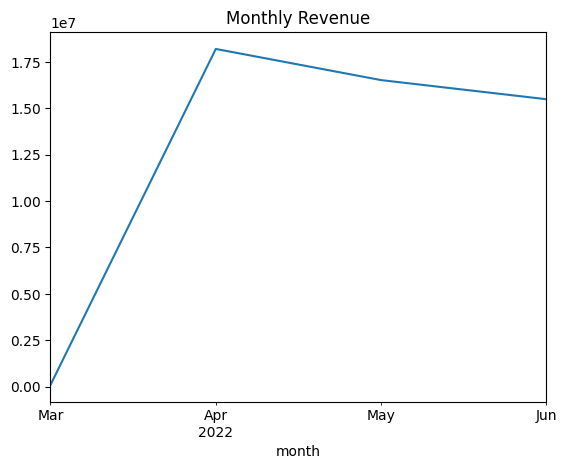

In [27]:
import matplotlib.pyplot as plt

monthly_sales = df.groupby('month')['revenue'].sum()

monthly_sales.plot(kind='line', title='Monthly Revenue')

plt.savefig('../images/monthly_revenue.png', bbox_inches='tight')
plt.show()

In [28]:
df.groupby('category')['revenue'].sum().sort_values(ascending=False).head(10)

category
Set              25574413.0
kurta            14068674.0
Western Dress     5819859.0
Top               3811430.0
Ethnic Dress       549448.0
Blouse             323361.0
Saree               94769.0
Bottom              81386.0
Dupatta               915.0
Name: revenue, dtype: float64

In [29]:
df.groupby('ship-state')['revenue'].sum().sort_values(ascending=False).head(10)

ship-state
MAHARASHTRA       8743630.0
KARNATAKA         7094688.0
TELANGANA         4506844.0
TAMIL NADU        4293145.0
UTTAR PRADESH     4239078.0
DELHI             2763495.0
WEST BENGAL       2309741.0
KERALA            2175864.0
ANDHRA PRADESH    1992106.0
HARYANA           1901108.0
Name: revenue, dtype: float64

In [30]:
df.groupby('fulfilment')['revenue'].sum()

fulfilment
Amazon    50324255.0
Name: revenue, dtype: float64

In [31]:
df['status'].value_counts()

status
Shipped    77596
Name: count, dtype: int64